# Heart Disease Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Data Loading

In [12]:
df = pd.read_csv('heart.csv')
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. Dataset Overview

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


The dataset contains 918 rows (samples) and 12 columns, including 7 numerical and 5 categorical.

Decoding of parameters:

In [14]:
feature_dict = {
    'Age': 'Patient age in years',
    'Sex': 'Gender (M: Male, F: Female)',
    'ChestPainType': 'Type of chest pain (ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic, TA: Typical Angina)',
    'RestingBP': 'Resting blood pressure (mm Hg)',
    'Cholesterol': 'Serum cholesterol (mg/dl)',
    'FastingBS': 'Fasting blood sugar > 120 mg/dl (0: False, 1: True)',
    'RestingECG': 'Resting electrocardiogram results (Normal, ST, LVH)',
    'MaxHR': 'Maximum heart rate achieved',
    'ExerciseAngina': 'Exercise-induced angina (Y: Yes, N: No)',
    'Oldpeak': 'ST depression induced by exercise relative to rest',
    'ST_Slope': 'Slope of the peak exercise ST segment (Up, Flat, Down)',
    'HeartDisease': 'Target variable (0: No heart disease, 1: Heart disease)'
}

Let's check the balance between No Disease and Disease in the data

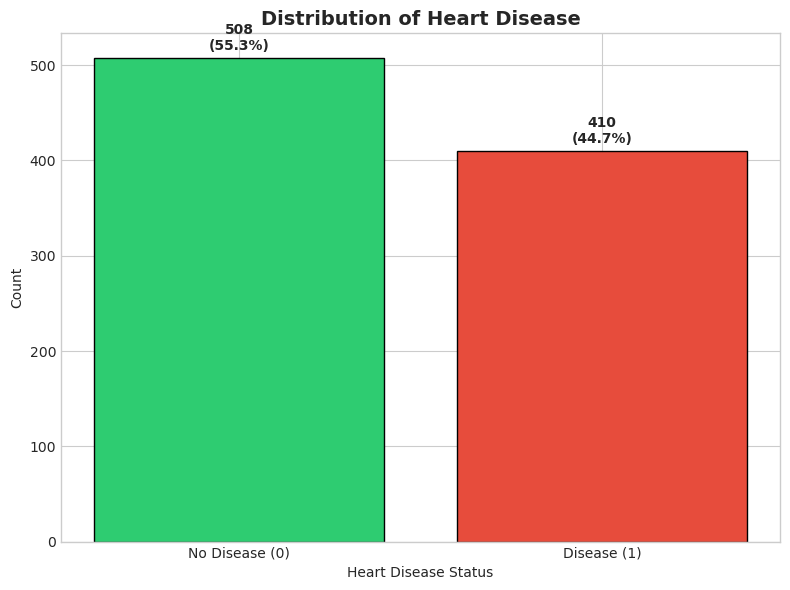

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 6))

heart_disease_counts = df['HeartDisease'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(['No Disease (0)', 'Disease (1)'], heart_disease_counts.values, color=colors, edgecolor='black')
ax1.set_title('Distribution of Heart Disease', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Heart Disease Status')

for bar, count in zip(bars, heart_disease_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}\n({count/len(df)*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

The incidence of diseases is slightly lower, but we can say that they are in balance.

## 3. Missing Values

In [20]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percentage
})

print(df[df.isnull()] if any(df.isnull().sum() > 0) else "No missing values")

zero_checks = {
    'RestingBP': (df['RestingBP'] == 0).sum(),
    'Cholesterol': (df['Cholesterol'] == 0).sum()
}

for col, count in zero_checks.items():
    if count > 0:
        print(f"{col}: {count} records with value 0 (medically suspicious)")
    else:
        print(f"{col}: No zero values found")

No missing values
RestingBP: 1 records with value 0 (medically suspicious)
Cholesterol: 172 records with value 0 (medically suspicious)


We will replace zero values ​​with averages to avoid introducing errors into subsequent analysis and to preserve the number of samples.

In [21]:
for col in ['RestingBP', 'Cholesterol']:
    zero_count = (df[col] == 0).sum()
    mean_value = df[df[col] > 0][col].mean()
    df.loc[df[col] == 0, col] = round(mean_value)
    print(f"{col}: {zero_count} zero values have been replaced with meaning value = {mean_value:.2f}")

RestingBP: 1 zero values have been replaced with meaning value = 132.54
Cholesterol: 172 zero values have been replaced with meaning value = 244.64


Let's check for outliers

In [23]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

outlier_summary = {}
for col in numerical_cols:
    data = df[col]
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_summary[col] = {
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Percentage': (len(outliers) / len(data)) * 100
    }
    
    print(f"{col}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Normal range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

Age:
  Q1: 47.00, Q3: 60.00, IQR: 13.00
  Normal range: [27.50, 79.50]
  Outliers: 0 (0.0%)
RestingBP:
  Q1: 120.00, Q3: 140.00, IQR: 20.00
  Normal range: [90.00, 170.00]
  Outliers: 27 (2.9%)
Cholesterol:
  Q1: 214.00, Q3: 267.00, IQR: 53.00
  Normal range: [134.50, 346.50]
  Outliers: 41 (4.5%)
MaxHR:
  Q1: 120.00, Q3: 156.00, IQR: 36.00
  Normal range: [66.00, 210.00]
  Outliers: 2 (0.2%)
Oldpeak:
  Q1: 0.00, Q3: 1.50, IQR: 1.50
  Normal range: [-2.25, 3.75]
  Outliers: 16 (1.7%)


Results of outlier detection using the IQR method show some outliers. Let's visualize them

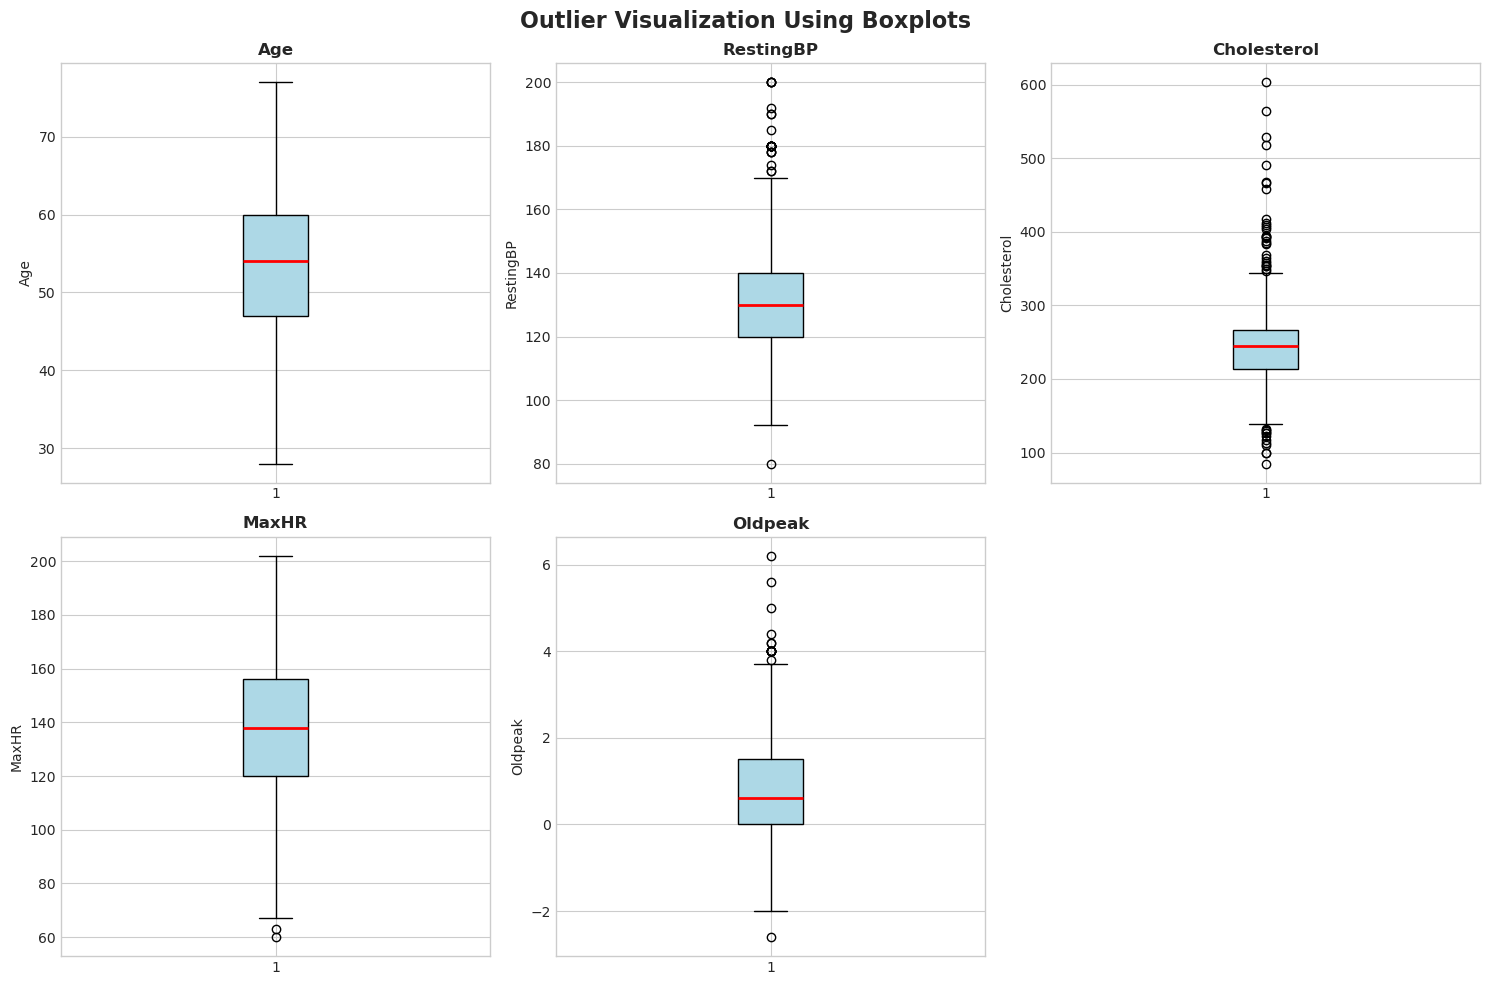

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    data = df[col]
    
    bp = axes[idx].boxplot(data, patch_artist=True, 
                            boxprops=dict(facecolor='lightblue'),
                            medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel(col)

fig.delaxes(axes[5])
plt.suptitle('Outlier Visualization Using Boxplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Check features effect on target variable

Let's check the categorical parameters

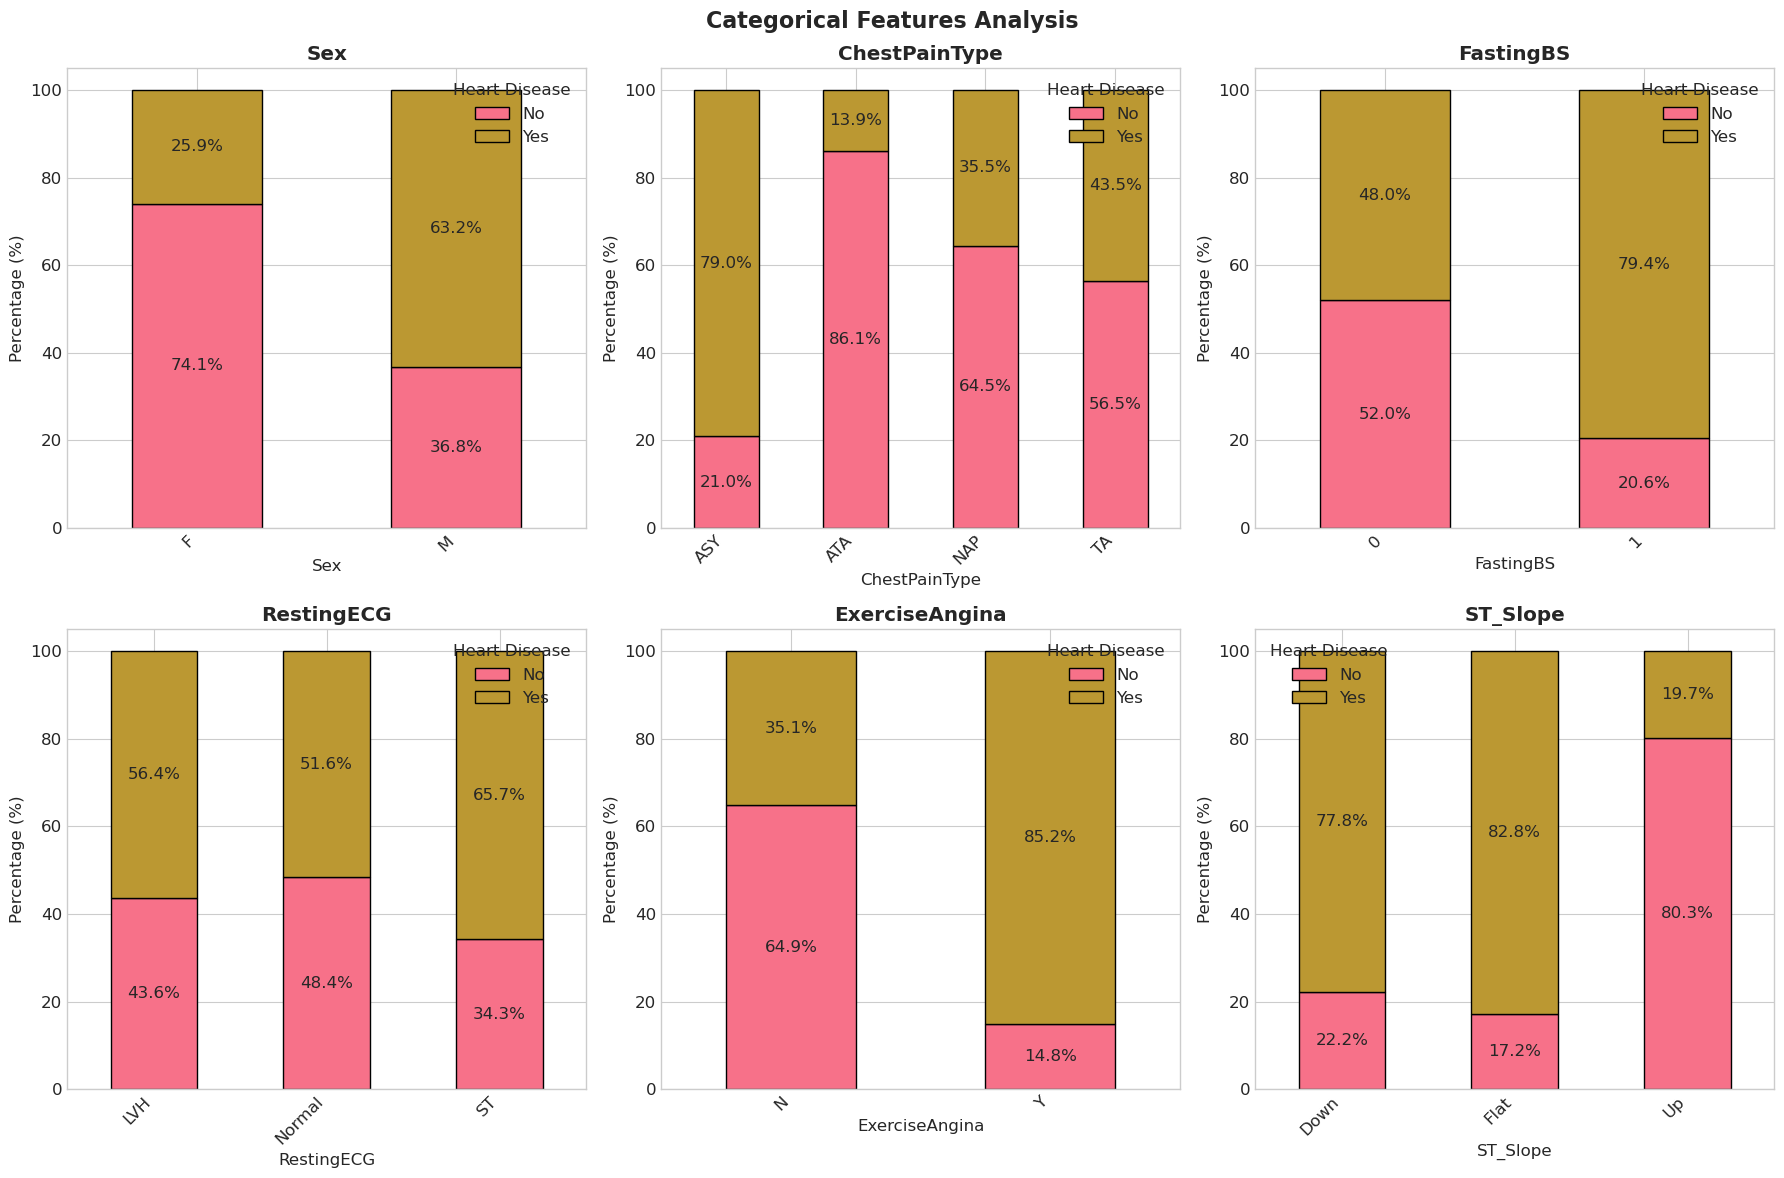

In [73]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    crosstab = pd.crosstab(df[col], df['HeartDisease'], normalize='index') * 100
    
    crosstab.plot(kind='bar', stacked=True, ax=axes[idx], edgecolor='black')
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(title='Heart Disease', labels=['No', 'Yes'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', label_type='center')

plt.suptitle('Categorical Features Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The distribution of cases shows that men have a higher incidence. Atypical angina and exercise-induced angina also have a higher incidence. The UP slope of the peak exercise ST segment shows the highest incidence.

Let's check the numerical parameters

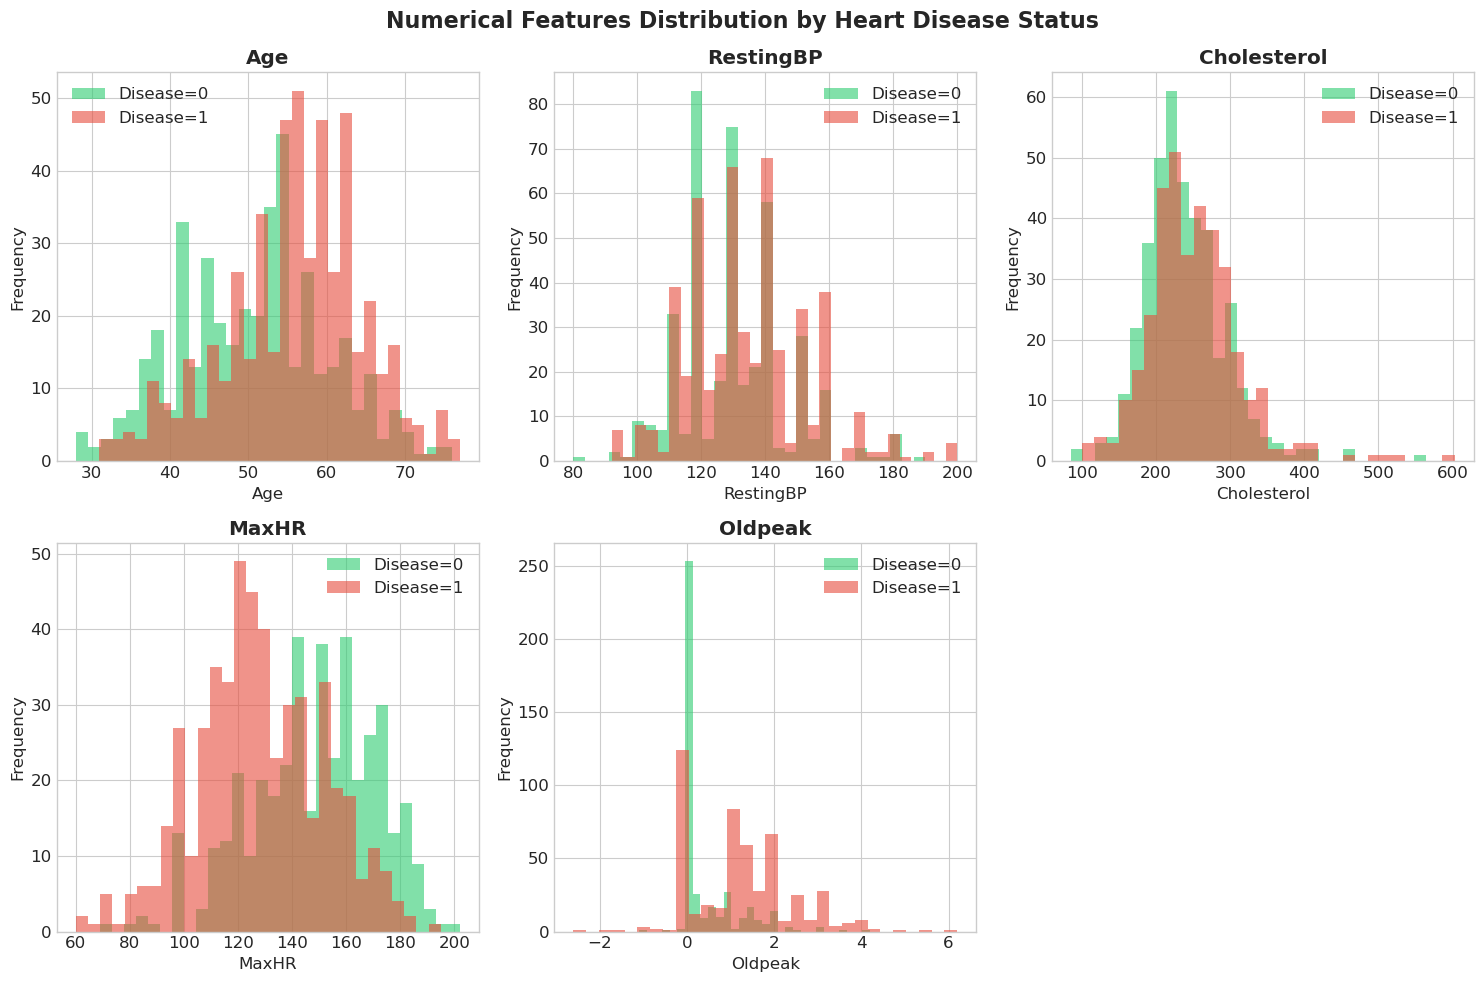

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    for disease_status in [0, 1]:
        subset = df[df['HeartDisease'] == disease_status]
        data = subset[col]
        if col in ['Cholesterol', 'RestingBP']:
            data = subset[subset[col] > 0][col]
        
        axes[idx].hist(data, alpha=0.6, bins=30, 
                       label=f'Disease={disease_status}',
                       color=['#2ecc71', '#e74c3c'][disease_status])
    
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

fig.delaxes(axes[5])
plt.suptitle('Numerical Features Distribution by Heart Disease Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

We see that the disease distribution is skewed to the right for age, while for maximum heart rate it is skewed to the left.

## Bivariate/Multivariate Analysis

We all know that the risk of heart disease increases with age. Let's look at the age distribution of disease and non-disease risk among groups of categorical variables.

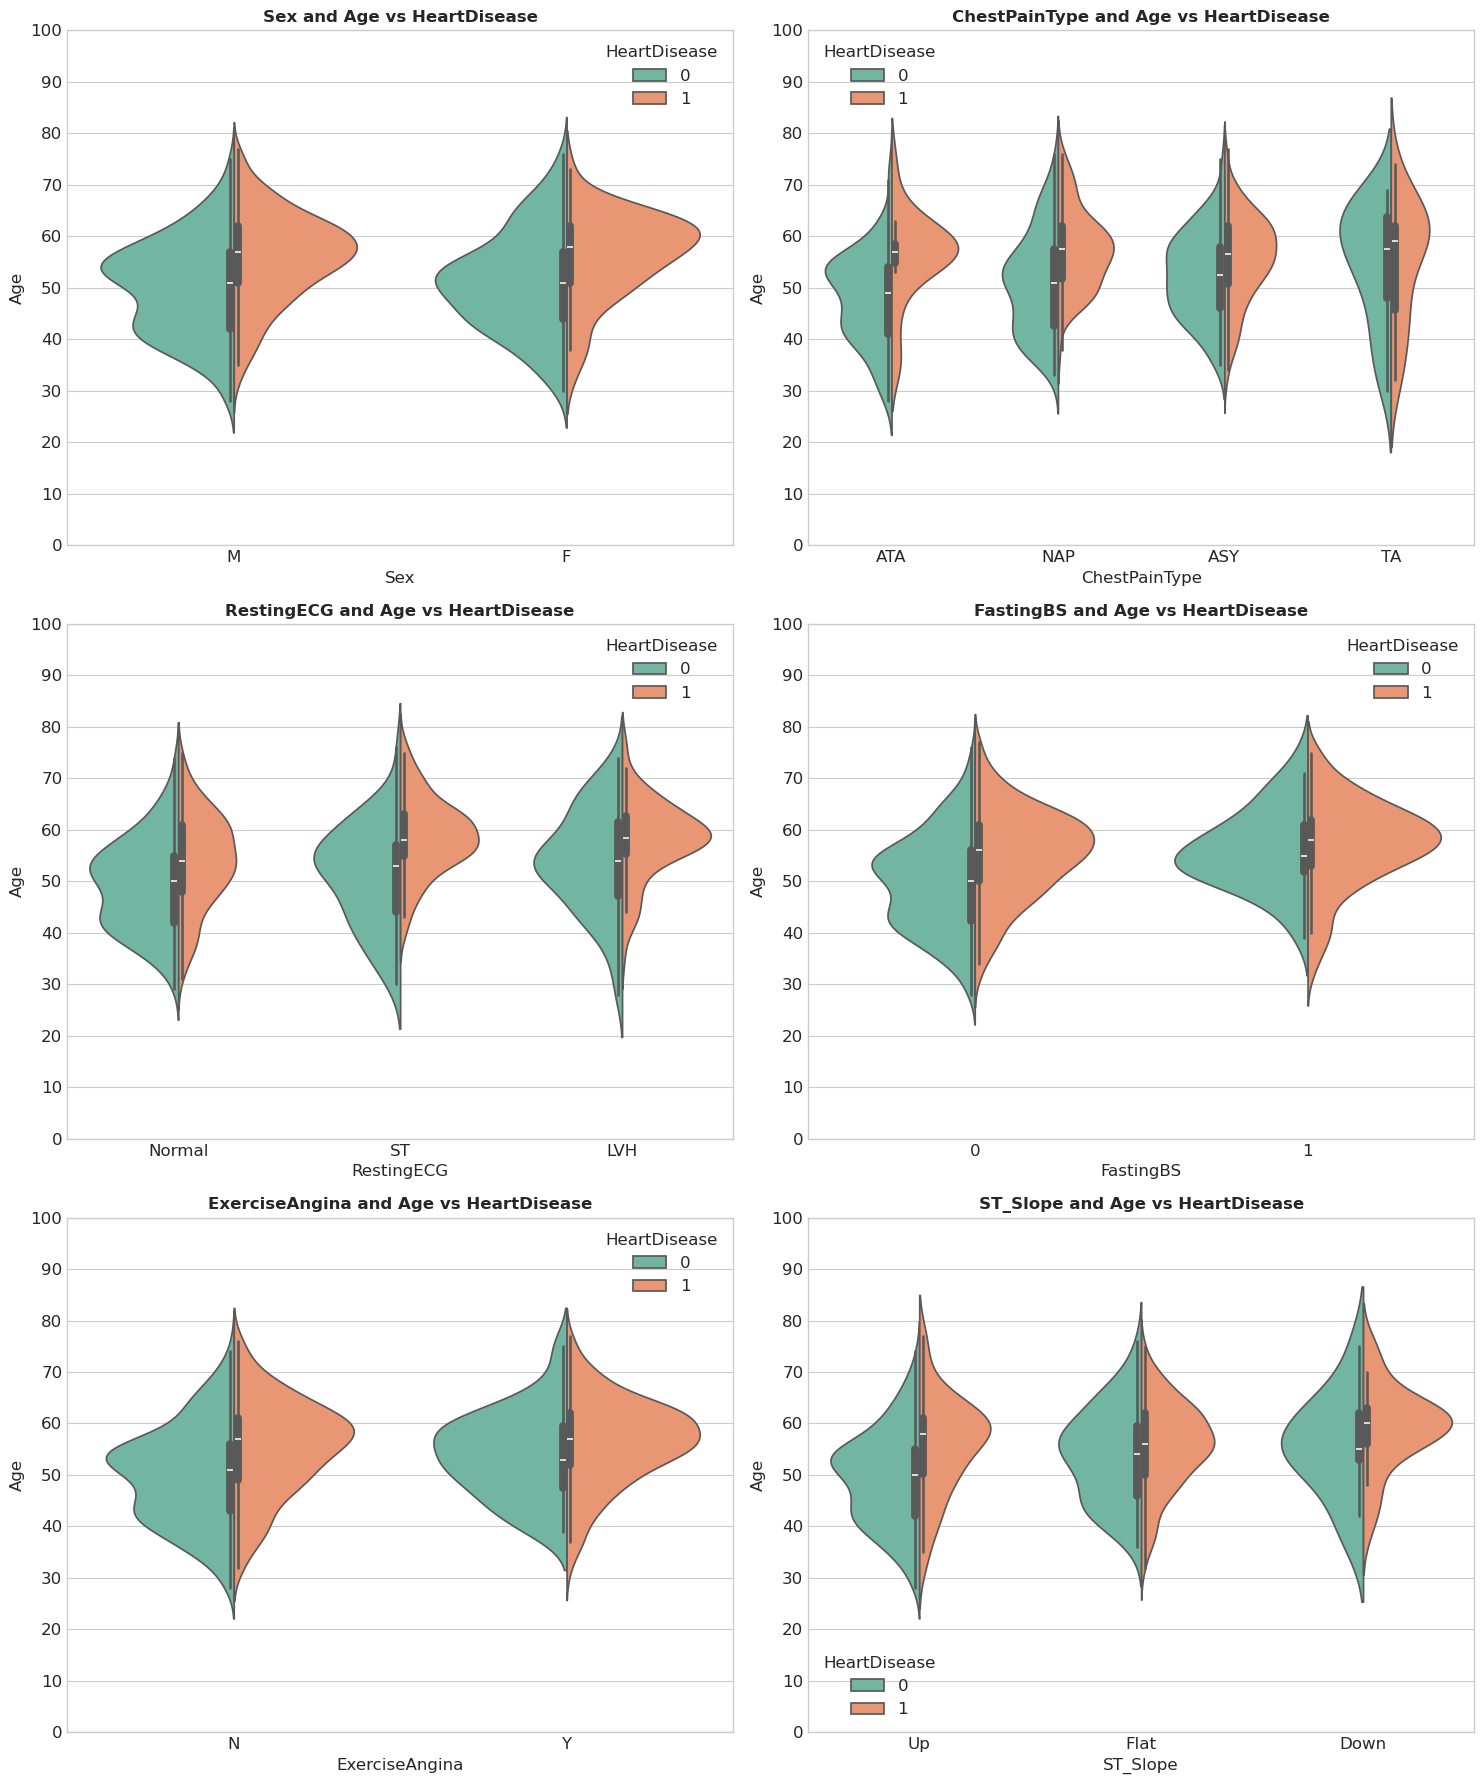

In [72]:
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG','FastingBS', 
                       'ExerciseAngina', 'ST_Slope']

n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
axes = axes.flatten()

for idx, column in enumerate(categorical_columns):
    sns.violinplot(data=df, x=column, y="Age", hue="HeartDisease", 
                   split=True, ax=axes[idx], palette="Set2")
    axes[idx].set_title(f'{column} and Age vs HeartDisease', fontsize=12, fontweight='bold')
    axes[idx].set_yticks(range(0, 110, 10))
    axes[idx].set_ylabel('Age')
    axes[idx].set_xlabel(column)

for idx in range(len(categorical_columns), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

As we see in all phenotypes, the age in cases of disease is higher than in cases of normality.

Let's now look at how the different parameters relate to each other.

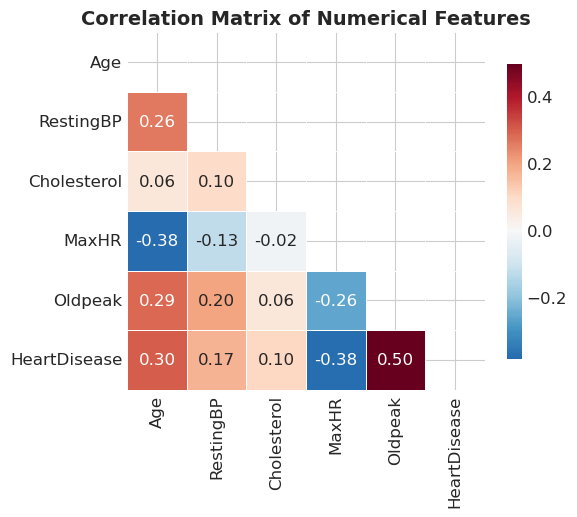

In [74]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']

corr_df = df[numerical_features].copy()
corr_df = corr_df[(corr_df['RestingBP'] > 0) & (corr_df['Cholesterol'] > 0)]

correlation_matrix = corr_df.corr()

plt.figure(figsize=(6, 6))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
We see a high positive correlation between Oldpeak and HeartDisease

For a more detailed analysis, let's visualize the pairwise relationships between all numerical features in the dataset.

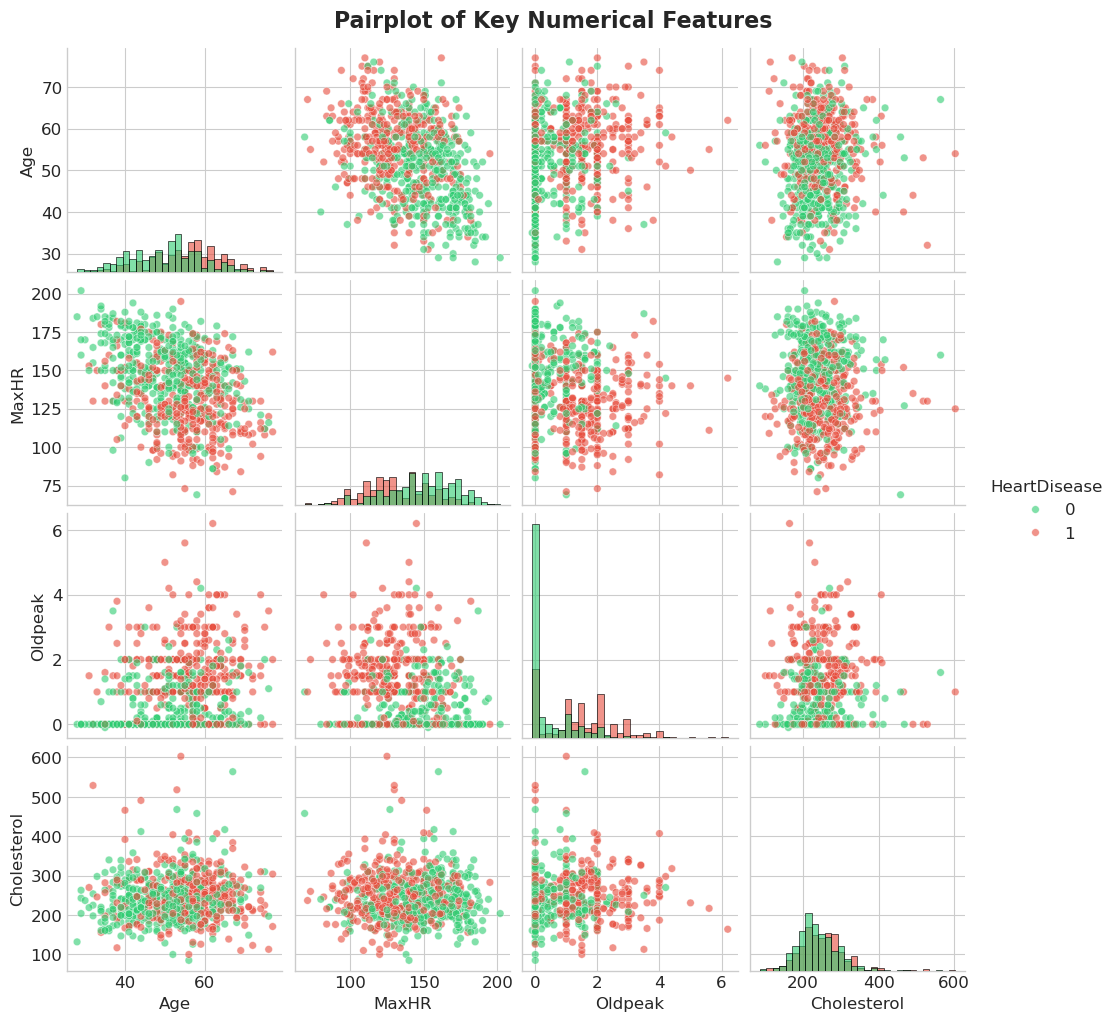

In [54]:
from sklearn.preprocessing import StandardScaler

pairplot_features = ['Age', 'MaxHR', 'Oldpeak', 'Cholesterol', 'HeartDisease']

pairplot_df = df[pairplot_features].copy()
pairplot_df = pairplot_df[pairplot_df['Cholesterol'] > 0]

sns.pairplot(pairplot_df, hue='HeartDisease', palette=['#2ecc71', '#e74c3c'],
             diag_kind='hist', plot_kws={'alpha': 0.6, 's': 30},
             diag_kws={'alpha': 0.6, 'bins': 30})
plt.suptitle('Pairplot of Key Numerical Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [31]:
Insights = {
    "1. Age vs MaxHR": """
    -Clear negative correlation (the older the patient, the lower the MaxHR)
    -Red dots (patients) predominantly at the bottom of the graph
    -Conclusion: Elderly patients with low MaxHR have an increased risk
    """,
    
    "2. Age vs Oldpeak": """
    -Oldpeak tends to increase with age
    -Red dots are concentrated in the area of ​​high Oldpeak (>1.5)
    -Conclusion: Age + high Oldpeak = a strong predictor of disease
    """,
    
    "3. MaxHR vs Oldpeak": """
    -Negative correlation (higher Oldpeak = lower MaxHR)
    -Clear separation: red dots in the lower left quadrant
    -Conclusion: the combination of low MaxHR and high Oldpeak is a dangerous sign
    """,
    
    "4. Cholesterol vs other signs": """
    -Weak correlation with other signs
    -Red and green dots are heavily intermixed
    -Conclusion: Cholesterol alone is not a strong predictor
    """,
    
    "5. Class Separability": """
    -The best separation is seen in the graphs involving MaxHR and Oldpeak
    -Cholesterol does not show a clear separation
    -Age shows a moderate separation
    """
}
for insight, description in Insights.items():
    print(f"{insight}")
    print("-" * len(insight))
    print(description)

1. Age vs MaxHR
---------------

    -Clear negative correlation (the older the patient, the lower the MaxHR)
    -Red dots (patients) predominantly at the bottom of the graph
    -Conclusion: Elderly patients with low MaxHR have an increased risk
    
2. Age vs Oldpeak
-----------------

    -Oldpeak tends to increase with age
    -Red dots are concentrated in the area of ​​high Oldpeak (>1.5)
    -Conclusion: Age + high Oldpeak = a strong predictor of disease
    
3. MaxHR vs Oldpeak
-------------------

    -Negative correlation (higher Oldpeak = lower MaxHR)
    -Clear separation: red dots in the lower left quadrant
    -Conclusion: the combination of low MaxHR and high Oldpeak is a dangerous sign
    
4. Cholesterol vs other signs
-----------------------------

    -Weak correlation with other signs
    -Red and green dots are heavily intermixed
    -Conclusion: Cholesterol alone is not a strong predictor
    
5. Class Separability
---------------------

    -The best separation i

In clinical practice, the two most important risk factors for cardiovascular disease are:
1. **Chest Pain Type** – reflects the nature of myocardial ischemia
2. **Exercise Angina** – indicates deterioration of blood supply to the heart during physical activity

Let's explore the **combined influence** of these two factors on the likelihood of heart disease.

ATA + ExerciseAngina=N: 9.6% heart disease rate
ATA + ExerciseAngina=Y: 52.9% heart disease rate
NAP + ExerciseAngina=N: 23.7% heart disease rate
NAP + ExerciseAngina=Y: 70.6% heart disease rate
ASY + ExerciseAngina=N: 62.3% heart disease rate
ASY + ExerciseAngina=Y: 90.2% heart disease rate
TA + ExerciseAngina=N: 42.5% heart disease rate
TA + ExerciseAngina=Y: 50.0% heart disease rate


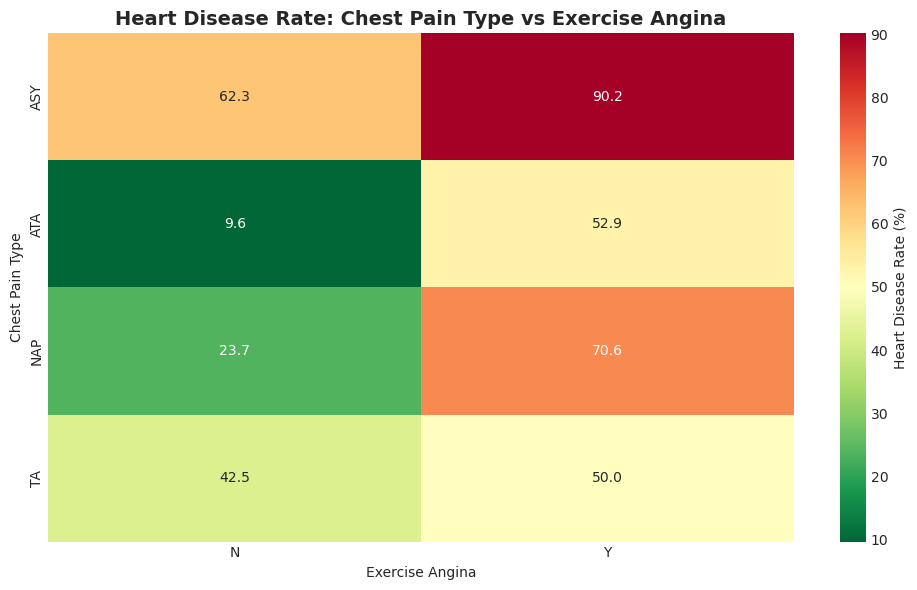

In [32]:
interaction_data = pd.crosstab([df['ChestPainType'], df['ExerciseAngina']], 
                                df['HeartDisease'], normalize='index') * 100


for chest_type in df['ChestPainType'].unique():
    for angina in ['N', 'Y']:
        key = (chest_type, angina)
        if key in interaction_data.index:
            disease_rate = interaction_data.loc[key, 1]
            print(f"{chest_type} + ExerciseAngina={angina}: {disease_rate:.1f}% heart disease rate")

pivot_table = df.pivot_table(values='HeartDisease', 
                              index='ChestPainType', 
                              columns='ExerciseAngina', 
                              aggfunc='mean') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Heart Disease Rate (%)'})
plt.title('Heart Disease Rate: Chest Pain Type vs Exercise Angina', 
          fontsize=14, fontweight='bold')
plt.xlabel('Exercise Angina')
plt.ylabel('Chest Pain Type')
plt.tight_layout()
plt.show()

Asymptomatic pain combined with any angina status during exertion indicates a very high probability of
heart disease.
And also Non-Anginal Pain with exercise anfina has high probability.

## Feature Engineering Suggestions

Create new dataframe for applying custom features

In [34]:
df_fe = df.copy()

### MaxHR percentage of predicted maximum

In [35]:
df_fe['MaxHR_Percentage'] = (df_fe['MaxHR'] / (220 - df_fe['Age'])) * 100

df_fe['MaxHR_Percentage'] = df_fe['MaxHR_Percentage'].clip(0, 150)

print(f"  Formule: MaxHR / (220 - Age) * 100")
print(f"  Range: {df_fe['MaxHR_Percentage'].min():.1f}% - {df_fe['MaxHR_Percentage'].max():.1f}%")
print(f"  Mean: {df_fe['MaxHR_Percentage'].mean():.1f}%")

print("\nComparing with raw MaxHR:")
print(f"  MaxHR (raw): corr with HeartDisease = {df_fe['MaxHR'].corr(df_fe['HeartDisease']):.3f}")
print(f"  MaxHR_Percentage (new): corr with HeartDisease = {df_fe['MaxHR_Percentage'].corr(df_fe['HeartDisease']):.3f}")


  Formule: MaxHR / (220 - Age) * 100
  Range: 35.5% - 117.5%
  Mean: 82.1%

Comparing with raw MaxHR:
  MaxHR (raw): corr with HeartDisease = -0.400
  MaxHR_Percentage (new): corr with HeartDisease = -0.335


Okay, that didn't work.

### Combined risk-score

In [40]:
from scipy.stats import pearsonr

risk_weights = {
    'ChestPainType_risk': {
        'ASY': 4,
        'TA': 3,
        'NAP': 2,
        'ATA': 1 
    },
    'ExerciseAngina_risk': {'Y': 2, 'N': 0},
    'Oldpeak_risk': lambda x: min(int(x * 2), 5)  # Oldpeak * 2, max 5
}

df_fe['ChestPainType_Risk'] = df_fe['ChestPainType'].map(risk_weights['ChestPainType_risk'])
df_fe['ExerciseAngina_Risk'] = df_fe['ExerciseAngina'].map(risk_weights['ExerciseAngina_risk'])
df_fe['Oldpeak_Risk'] = df_fe['Oldpeak'].apply(risk_weights['Oldpeak_risk'])

df_fe['Combined_Risk_Score'] = (df_fe['ChestPainType_Risk'] + 
                                 df_fe['ExerciseAngina_Risk'] + 
                                 df_fe['Oldpeak_Risk'])

df_fe['Combined_Risk_Score_Normalized'] = (df_fe['Combined_Risk_Score'] / 
                                            df_fe['Combined_Risk_Score'].max() * 10)

print("New feature created: 'Combined_Risk_Score'")
print(f"  Components:")
print(f"    - ChestPainType risk (ASY=4, TA=3, NAP=2, ATA=1)")
print(f"    - ExerciseAngina risk (Y=2, N=0)")
print(f"    - Oldpeak risk (Oldpeak * 2, max=5)")
print(f"\n  Range of Combined_Risk_Score: {df_fe['Combined_Risk_Score'].min()} - {df_fe['Combined_Risk_Score'].max()}")
print(f"  Mean: {df_fe['Combined_Risk_Score'].mean():.2f}")
print(f"  Median: {df_fe['Combined_Risk_Score'].median():.2f}")
print(f"  Standard Deviation: {df_fe['Combined_Risk_Score'].std():.2f}")


df_fe['ChestPainType_Encoded'] = df_fe['ChestPainType'].map({'ASY': 4, 'TA': 3, 'NAP': 2, 'ATA': 1})
df_fe['ExerciseAngina_Encoded'] = df_fe['ExerciseAngina'].map({'Y': 1, 'N': 0})

print("\nORIGINAL FEATURES (correlation with HeartDisease):")
print("-" * 50)

original_features = {
    'Age': df_fe['Age'].corr(df_fe['HeartDisease']),
    'MaxHR': df_fe['MaxHR'].corr(df_fe['HeartDisease']),
    'Oldpeak': df_fe['Oldpeak'].corr(df_fe['HeartDisease']),
    'Cholesterol': df_fe['Cholesterol'].corr(df_fe['HeartDisease']),
    'ChestPainType (encoded)': df_fe['ChestPainType_Encoded'].corr(df_fe['HeartDisease']),
    'ExerciseAngina (encoded)': df_fe['ExerciseAngina_Encoded'].corr(df_fe['HeartDisease'])
}

for feature_name, corr in original_features.items():
    print(f"  {feature_name:30}: {corr:+.4f}")

print("\nNEW FEATURES (correlation with HeartDisease):")
print("-" * 50)

new_features = {
    'ChestPainType_Risk': df_fe['ChestPainType_Risk'].corr(df_fe['HeartDisease']),
    'ExerciseAngina_Risk': df_fe['ExerciseAngina_Risk'].corr(df_fe['HeartDisease']),
    'Oldpeak_Risk': df_fe['Oldpeak_Risk'].corr(df_fe['HeartDisease']),
    'Combined_Risk_Score': df_fe['Combined_Risk_Score'].corr(df_fe['HeartDisease']),
    'Combined_Risk_Score_Normalized': df_fe['Combined_Risk_Score_Normalized'].corr(df_fe['HeartDisease'])
}

for feature_name, corr in new_features.items():
    print(f"  {feature_name:30}: {corr:+.4f}")

New feature created: 'Combined_Risk_Score'
  Components:
    - ChestPainType risk (ASY=4, TA=3, NAP=2, ATA=1)
    - ExerciseAngina risk (Y=2, N=0)
    - Oldpeak risk (Oldpeak * 2, max=5)

  Range of Combined_Risk_Score: -2 - 11
  Mean: 5.29
  Median: 5.00
  Standard Deviation: 3.13

ORIGINAL FEATURES (correlation with HeartDisease):
--------------------------------------------------
  Age                           : +0.2820
  MaxHR                         : -0.4004
  Oldpeak                       : +0.4040
  Cholesterol                   : +0.0949
  ChestPainType (encoded)       : +0.5370
  ExerciseAngina (encoded)      : +0.4943

NEW FEATURES (correlation with HeartDisease):
--------------------------------------------------
  ChestPainType_Risk            : +0.5370
  ExerciseAngina_Risk           : +0.4943
  Oldpeak_Risk                  : +0.4231
  Combined_Risk_Score           : +0.6104
  Combined_Risk_Score_Normalized: +0.6104


The engineered Combined_Risk_Score achieved a correlation of +0.6104 with Heart Disease, outperforming the best original feature (ChestPainType: +0.5370) by 13.7%. This composite feature effectively integrates chest pain type, exercise angina, and ST-depression (Oldpeak) into a single clinically interpretable risk score ranging from -2 to 11 points.

## Statistical Testing

In [41]:
from scipy.stats import ttest_ind, chi2_contingency

print("\nT-Tests (Numerical Features vs Heart Disease):")

for col in ['Age', 'MaxHR', 'Oldpeak']:
    group_0 = df[df['HeartDisease'] == 0][col]
    group_1 = df[df['HeartDisease'] == 1][col]
    
    if col == 'Cholesterol':
        group_0 = group_0[group_0 > 0]
        group_1 = group_1[group_1 > 0]
    
    t_stat, p_value = ttest_ind(group_0, group_1)
    significance = "SIGNIFICANT" if p_value < 0.05 else "Not significant"
    print(f"{col:12}: t={t_stat:.3f}, p={p_value:e} -> {significance}")

print("\n\nChi-Square Tests (Categorical Features vs Heart Disease):")
print("-" * 50)

for col in ['Sex', 'ChestPainType', 'FastingBS', 'ExerciseAngina', 'ST_Slope']:
    contingency = pd.crosstab(df[col], df['HeartDisease'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    significance = "SIGNIFICANT" if p_value < 0.05 else "Not significant"
    print(f"{col:15}: chi2={chi2:.3f}, p={p_value:e} -> {significance}")


T-Tests (Numerical Features vs Heart Disease):
Age         : t=-8.897, p=3.007953e-18 -> SIGNIFICANT
MaxHR       : t=13.225, p=1.137786e-36 -> SIGNIFICANT
Oldpeak     : t=-13.365, p=2.390772e-37 -> SIGNIFICANT


Chi-Square Tests (Categorical Features vs Heart Disease):
--------------------------------------------------
Sex            : chi2=84.145, p=4.597617e-20 -> SIGNIFICANT
ChestPainType  : chi2=268.067, p=8.083728e-58 -> SIGNIFICANT
FastingBS      : chi2=64.321, p=1.057302e-15 -> SIGNIFICANT
ExerciseAngina : chi2=222.259, p=2.907808e-50 -> SIGNIFICANT
ST_Slope       : chi2=355.918, p=5.167638e-78 -> SIGNIFICANT


## Conclusions

This dataset is well-suited for heart disease prediction with several strong clinical predictors identified. The engineered composite risk score significantly enhances predictive capability. The analysis confirms known medical knowledge while providing data-driven risk stratification. With appropriate preprocessing and feature engineering, this dataset can support development of accurate clinical decision support tools.

The most important takeaway: Combining multiple clinical indicators into a single risk score produces better predictions than any individual factor alone, and the strongest risk signal comes from the triad of asymptomatic chest pain, exercise-induced angina, and significant ST depression.